In [162]:
import numpy as np
import pandas as pd

In [163]:
df = pd.read_csv('spam.csv', encoding='cp1252')

In [164]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4793,ham,Sorry that was my uncle. I.ll keep in touch,NaN,NaN,NaN
4563,ham,Tell me again what your address is,NaN,NaN,NaN
105,ham,Thanks a lot for your wishes on my birthday. T...,NaN,NaN,NaN
893,ham,It's ok i noe u're busy but i'm really too bor...,NaN,NaN,NaN
2503,ham,Fwiw the reason I'm only around when it's time...,NaN,NaN,NaN


In [165]:
df.shape

(5572, 5)

In [166]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocressing
# 4. Model BUilding
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. DATA CLEANING

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [169]:
# Drop Last 3 Columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [170]:
df.sample(5)

,v1,v2
3909,ham,She.s good. She was wondering if you wont say ...
5409,ham,There is a first time for everything :)
900,ham,Probably money worries. Things are coming due ...
638,ham,"What will we do in the shower, baby?"
4029,ham,"Cool, I'll text you in a few"


In [171]:
#Renaming The columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2675,ham,I'm sick !! I'm needy !! I want you !! *pouts*...
4910,ham,Love that holiday Monday feeling even if I hav...
4469,ham,"Lemme know when I can swing by and pick up, I'..."
1555,ham,Ok i found dis pierre cardin one which looks n...
1541,ham,Do u konw waht is rael FRIENDSHIP Im gving yuo...


In [172]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()

In [173]:
df['target']=encoder.fit_transform(df['target'])

In [174]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [175]:
# missing values check
df.isnull().sum()

target    0
text      0
dtype: int64

In [176]:
#check for duplicate
df.duplicated().sum()

403

In [177]:
#remove duplicate 
df= df.drop_duplicates(keep='first')

In [178]:
df.duplicated().sum()

0

In [179]:
df.shape

(5169, 2)

## 2. EDA

In [181]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [182]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

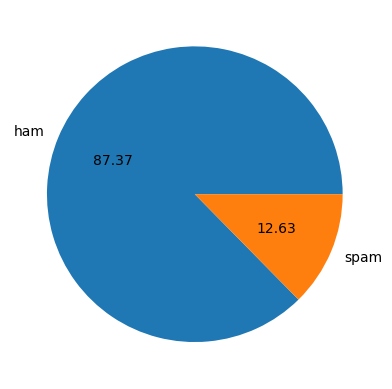

In [183]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [184]:
# Data is imbalanced

In [185]:
df = df.copy()
df['num_characters'] = df['text'].apply(len)


In [186]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [187]:
# num of words
import re
def count_words(text):
    return len(text.split())

# Function to count sentences using basic punctuation (., ?, !)
def count_sentences(text):
    return len(re.findall(r'[.!?]+', text))

# Apply the functions
df['num_words'] = df['text'].apply(count_words)
df['num_sentences'] = df['text'].apply(count_sentences)

# Display result
df[['text', 'num_words', 'num_sentences']].head()

,text,num_words,num_sentences
0,"Go until jurong point, crazy.. Available only ...",20,3
1,Ok lar... Joking wif u oni...,6,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,28,1
3,U dun say so early hor... U c already then say...,11,2
4,"Nah I don't think he goes to usf, he lives aro...",13,0


In [188]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [189]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,1.846779
std,58.236293,11.068488,1.745441
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,2.000000
75%,117.000000,22.000000,3.000000
max,910.000000,171.000000,39.000000


In [190]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.692648
std,56.358207,11.116240,1.681598
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,1.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,39.000000


In [191]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,2.912711
std,30.137753,5.967672,1.806610
min,13.000000,2.000000,0.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


In [192]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

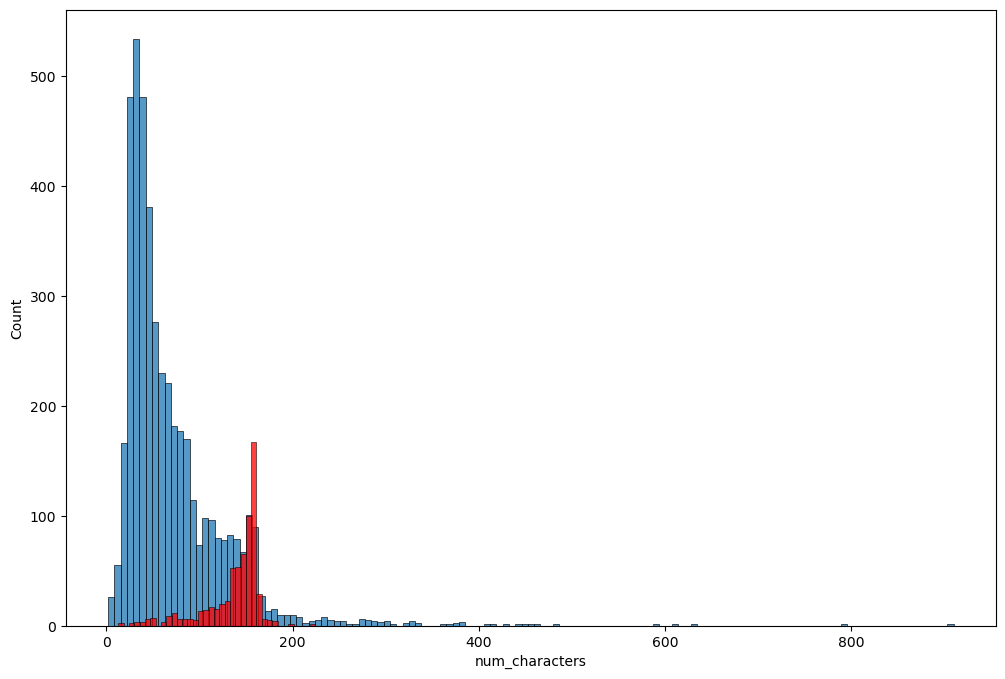

In [193]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

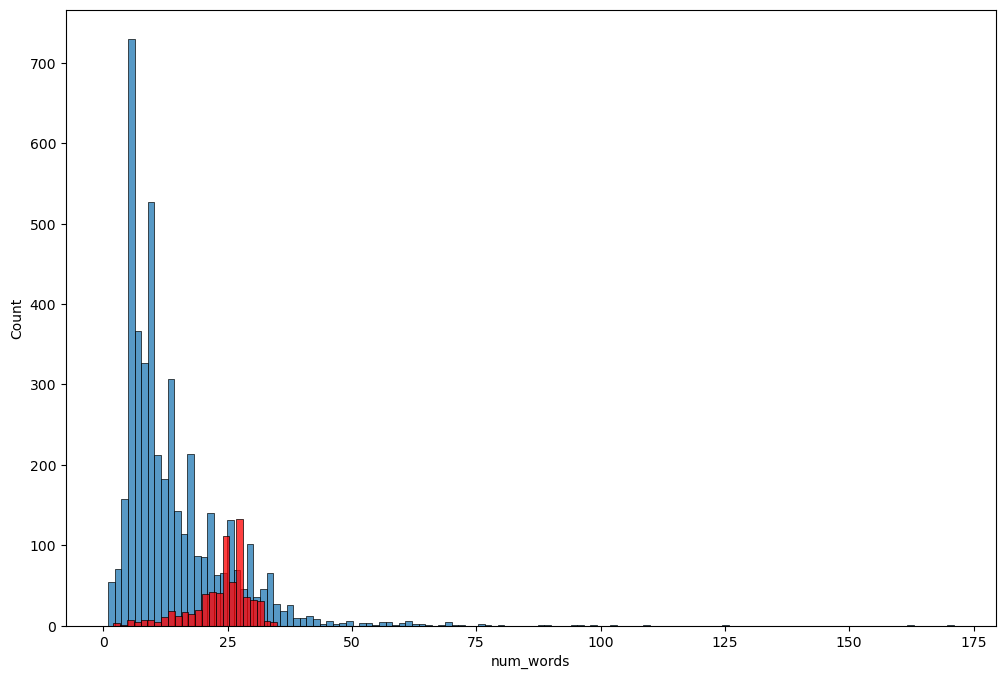

In [194]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

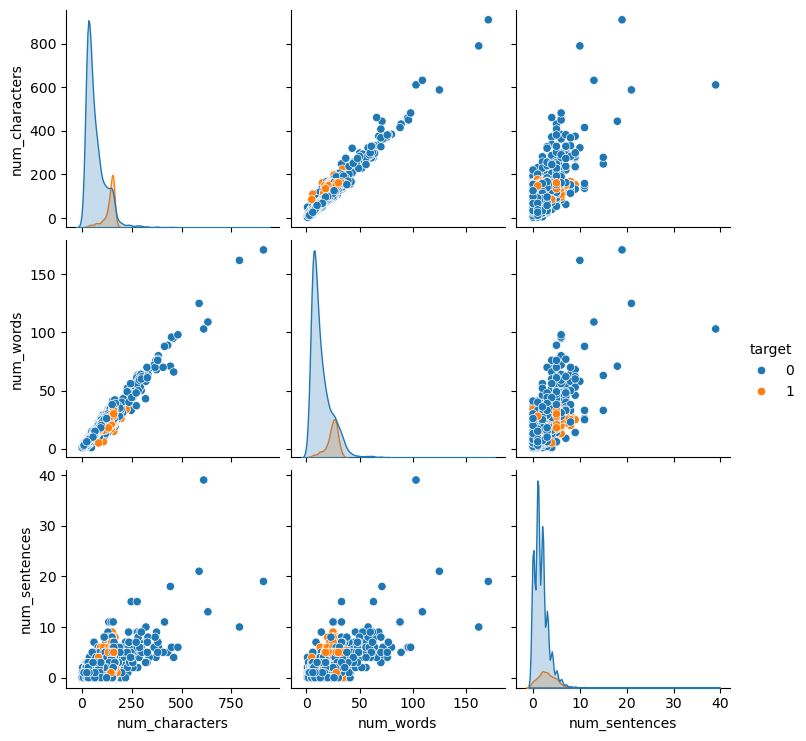

In [195]:
sns.pairplot(df,hue='target')

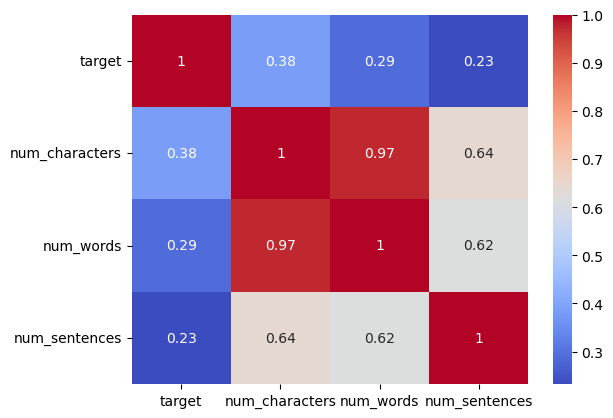

In [196]:

# Only select numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

# Plot heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


## Data Preprocessing
* lower case
* Tokenization
* Removing Special Characters
* removing stop words and punctuations
* stemming

In [198]:
import string

# List of common stopwords
stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself',
             'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself',
             'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
             'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
             'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as',
             'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through',
             'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on',
             'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where',
             'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such',
             'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will',
             'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn',
             'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan',
             'shouldn', 'wasn', 'weren', 'won', 'wouldn']

# Basic stemmer
def stem_word(word):
    suffixes = ['ing', 'ly', 'es', 'ed', 's']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[:-len(suffix)]
    return word

def transform_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stopwords]

    # Stemming
    stemmed_tokens = [stem_word(word) for word in tokens]

    # Join back into string
    return " ".join(stemmed_tokens)


In [199]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'im gonna home soon dont want talk stuff anymore tonight k ive cri enough today'

In [200]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [201]:
df['transformed_text']=df['text'].apply(transform_text)

In [202]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong point crazy available bugi n great w...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar jok wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entry 2 wkly comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say ear hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah dont think goe usf liv around though


In [203]:
from wordcloud import WordCloud
wc= WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [204]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

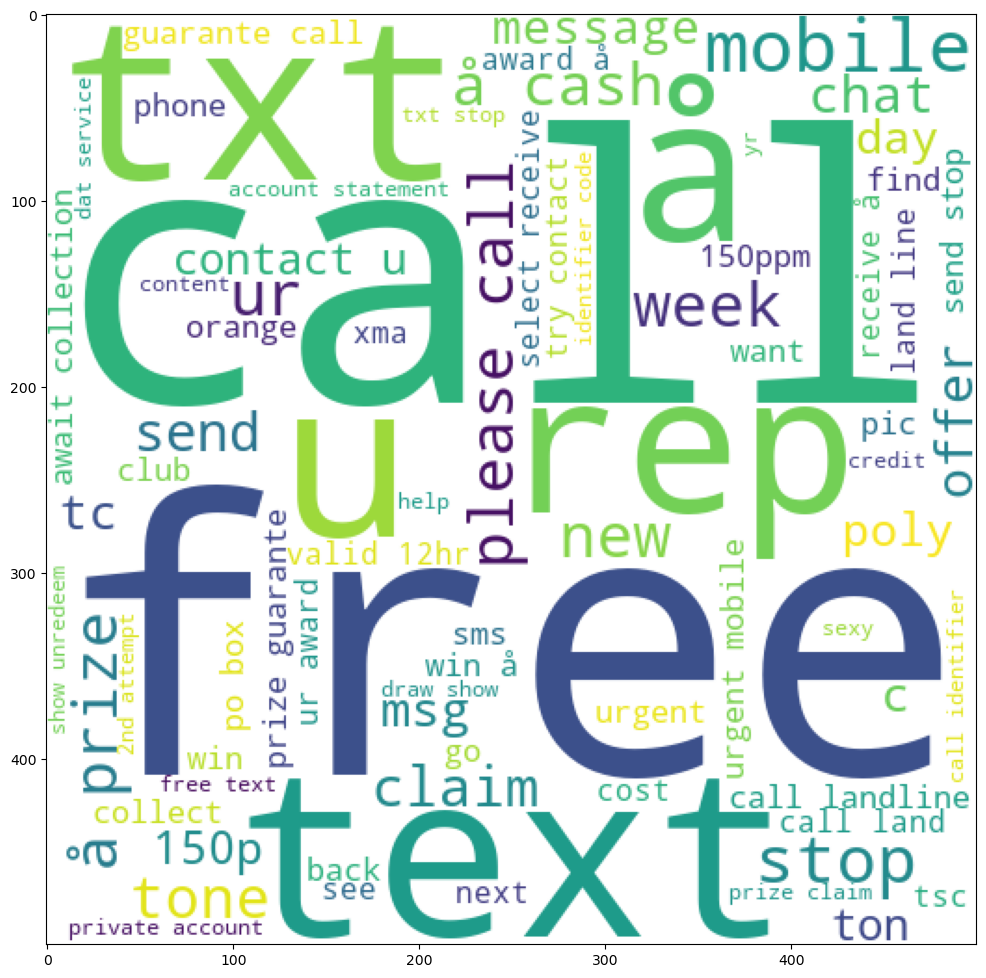

In [205]:
plt.figure(figsize=(12,15))
plt.imshow(spam_wc)

In [206]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

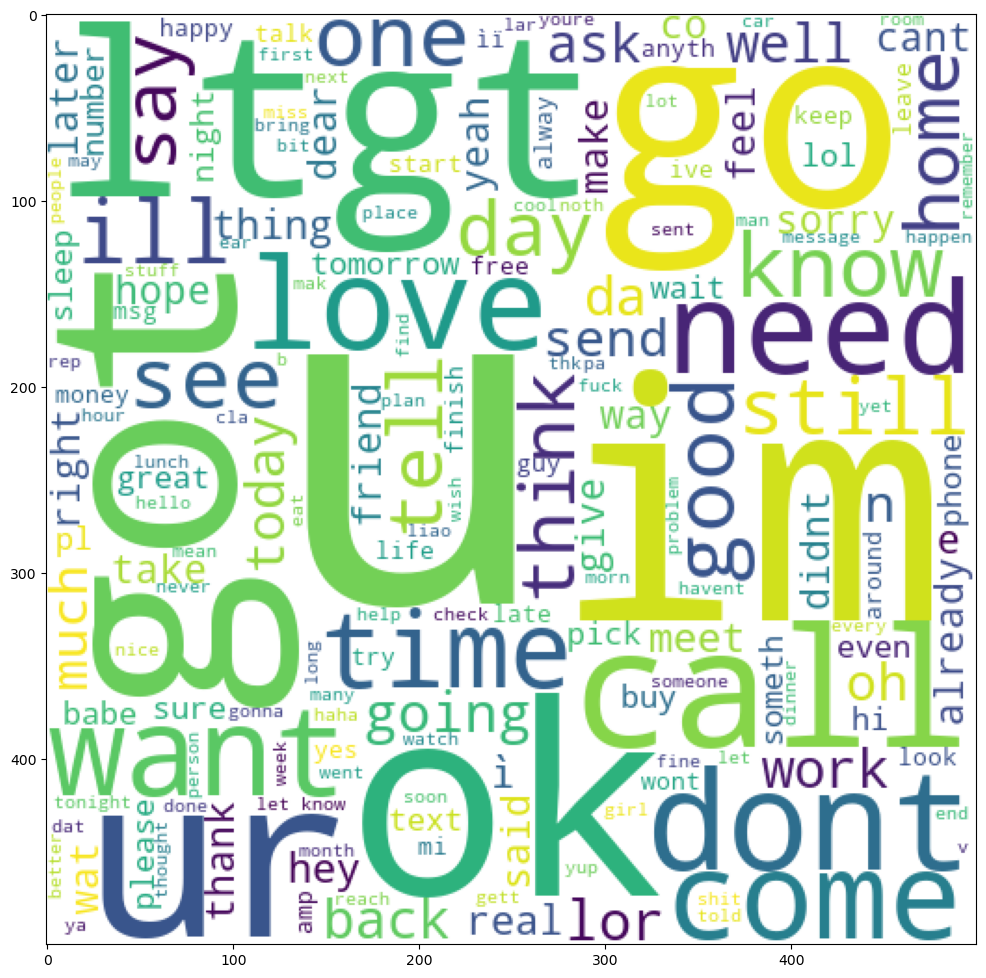

In [207]:
plt.figure(figsize=(12,15))
plt.imshow(ham_wc)

In [208]:
#df[df['target']==1]['transformed_text'].tolist()

In [209]:
spam_corpus=[]
for mes in df[df['target']==1]['transformed_text'].tolist():
    for words in mes.split():
        spam_corpus.append(words)

In [210]:
len(spam_corpus)

10806

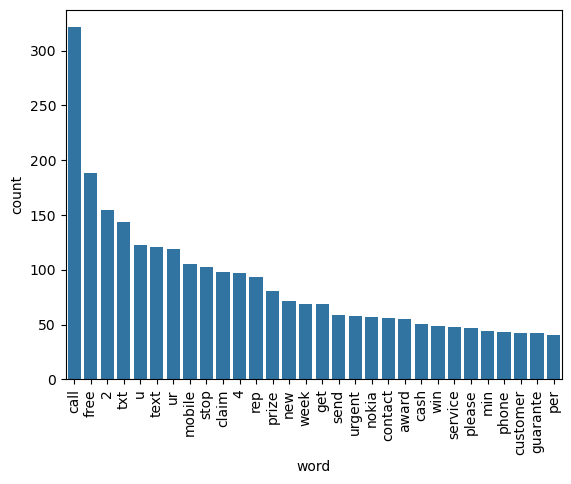

In [211]:
from collections import Counter 
# Get the 30 most common words
most_common_words = Counter(spam_corpus).most_common(30)

# Convert to DataFrame
df_common = pd.DataFrame(most_common_words, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df_common)
plt.xticks(rotation=90)
plt.show()

In [212]:
ham_corpus=[]
for mes in df[df['target']==0]['transformed_text'].tolist():
    for words in mes.split():
        ham_corpus.append(words)

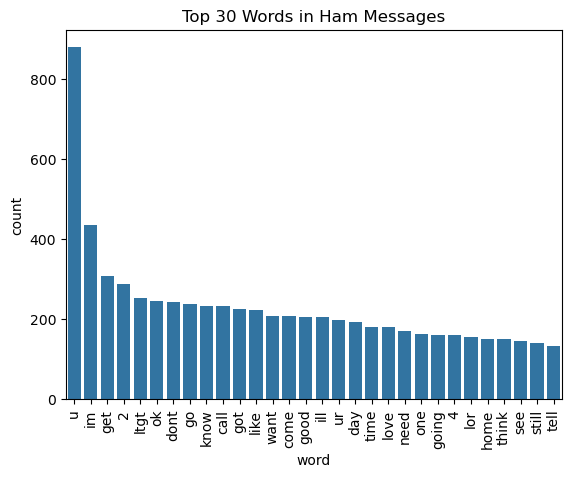

In [213]:
# Get the 30 most common words from ham messages
most_common_ham = Counter(ham_corpus).most_common(30)

# Convert to DataFrame
df_ham_common = pd.DataFrame(most_common_ham, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df_ham_common)
plt.xticks(rotation=90)
plt.title("Top 30 Words in Ham Messages")
plt.show()

## MODEL BUILDING

In [215]:
#BAG OF WORDS


In [216]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv= CountVectorizer()
tfidf=TfidfVectorizer()

In [217]:
X= tfidf.fit_transform(df['transformed_text']).toarray()

In [218]:
X.shape

(5169, 8415)

In [219]:
y=df['target'].values

In [220]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [221]:
from sklearn.model_selection import train_test_split

In [222]:
X_train, X_test , y_train , y_test= train_test_split(X,y,test_size=0.2,random_state=2)

In [223]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB , BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score

In [224]:
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()


In [225]:
# Train the model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict
y_pred1 = gnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

Accuracy: 0.8800773694390716
Confusion Matrix:
 [[793 103]
 [ 21 117]]
Precision: 0.5318181818181819


In [226]:
#multinomial naive bayes
mnb.fit(X_train, y_train)

# Predict
y_pred2 = mnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))

Accuracy: 0.9535783365570599
Confusion Matrix:
 [[896   0]
 [ 48  90]]
Precision: 1.0


In [227]:
#bernoulli
bnb.fit(X_train, y_train)

# Predict
y_pred3 = bnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))

Accuracy: 0.9709864603481625
Confusion Matrix:
 [[894   2]
 [ 28 110]]
Precision: 0.9821428571428571


In [228]:
# tfidf --> mnb

In [229]:
!pip install xgboost


In [230]:

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

In [231]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier ()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='11')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [232]:
clfs = {
    'Logistic Regression': LogisticRegression(penalty='l1', solver='liblinear'),
    'SVC': SVC(),
    'Multinomial NB': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
    # 'XGBoost': XGBClassifier()  # Only include if xgboost is installed
}


In [233]:

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [234]:
train_classifier(svc,X_train,y_train,X_test,y_test) 

(0.9729206963249516, 0.9741379310344828)

In [235]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  Logistic Regression
Accuracy -  0.9468085106382979
Precision -  0.9368421052631579
For  SVC
Accuracy -  0.9671179883945842
Precision -  0.9905660377358491
For  Multinomial NB
Accuracy -  0.9535783365570599
Precision -  1.0
For  Decision Tree
Accuracy -  0.9526112185686654
Precision -  0.8296296296296296
For  KNN
Accuracy -  0.8974854932301741
Precision -  1.0
For  Random Forest
Accuracy -  0.9661508704061895
Precision -  1.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.9632495164410058
Precision -  0.923728813559322
For  Bagging
Accuracy -  0.9555125725338491
Precision -  0.8898305084745762
For  Extra Trees
Accuracy -  0.9700193423597679
Precision -  0.9734513274336283
For  Gradient Boosting
Accuracy -  0.9584139264990329
Precision -  0.9357798165137615


In [236]:
"""# Initialize the models
clfs = {
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'MultinomialNB': MultinomialNB(),
    'DecisionTree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'RandomForest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'ExtraTrees': ExtraTreesClassifier(),
    'GradientBoosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()  # After installing XGBoost
}

# Initialize lists to store scores
accuracy_scores = []
precision_scores = []

# Train each model, make predictions, and calculate metrics
for name, model in clfs.items():
    model.fit(X_train, y_train)      # Fit model to the training data
    y_pred = model.predict(X_test)  # Make predictions on the test data

    # Calculate and append the metrics
    accuracy_scores.append(accuracy_score(y_test, y_pred))  # Accuracy
    precision_scores.append(precision_score(y_test, y_pred))  # Precision

# Check if both lists have the same length before creating the DataFrame
if len(accuracy_scores) == len(precision_scores):
    # Create the DataFrame
    performance_df = pd.DataFrame({
        'Algorithm': list(clfs.keys()),
        'Accuracy': accuracy_scores,
        'Precision': precision_scores
    }).sort_values('Precision', ascending=False)

    # Display the performance metrics
    print(performance_df)
else:
    print(f"Mismatch in the length of accuracy and precision scores. Accuracy: {len(accuracy_scores)}, Precision: {len(precision_scores)}")
"""

'# Initialize the models\nclfs = {\n    \'LogisticRegression\': LogisticRegression(),\n    \'SVC\': SVC(),\n    \'MultinomialNB\': MultinomialNB(),\n    \'DecisionTree\': DecisionTreeClassifier(),\n    \'KNN\': KNeighborsClassifier(),\n    \'RandomForest\': RandomForestClassifier(),\n    \'AdaBoost\': AdaBoostClassifier(),\n    \'Bagging\': BaggingClassifier(),\n    \'ExtraTrees\': ExtraTreesClassifier(),\n    \'GradientBoosting\': GradientBoostingClassifier(),\n    \'XGBoost\': XGBClassifier()  # After installing XGBoost\n}\n\n# Initialize lists to store scores\naccuracy_scores = []\nprecision_scores = []\n\n# Train each model, make predictions, and calculate metrics\nfor name, model in clfs.items():\n    model.fit(X_train, y_train)      # Fit model to the training data\n    y_pred = model.predict(X_test)  # Make predictions on the test data\n\n    # Calculate and append the metrics\n    accuracy_scores.append(accuracy_score(y_test, y_pred))  # Accuracy\n    precision_scores.append(pr

In [237]:

performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [238]:

performance_df1

,Algorithm,variable,value
0,MultinomialNB,Accuracy,0.953578
1,KNN,Accuracy,0.897485
2,RandomForest,Accuracy,0.970019
3,SVC,Accuracy,0.967118
4,LogisticRegression,Accuracy,0.941973
5,ExtraTrees,Accuracy,0.973888
6,GradientBoosting,Accuracy,0.958414
7,AdaBoost,Accuracy,0.963250
8,XGBoost,Accuracy,0.970019
9,Bagging,Accuracy,0.959381


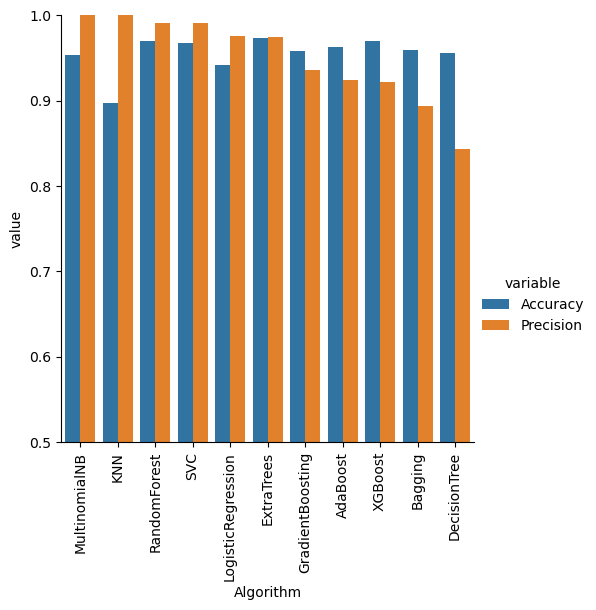

In [239]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [240]:
#Model 
# 1. Change the max_feautures parameter of TfIdf

In [241]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)


In [242]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)


In [243]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [244]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [245]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)


In [246]:

new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KNN,0.897485,1.000000,0.897485,1.000000,0.897485,1.000000,0.897485,1.000000
1,SVC,0.967118,0.990566,0.967118,0.990566,0.967118,0.990566,0.967118,0.990566
2,AdaBoost,0.963250,0.923729,0.963250,0.923729,0.963250,0.923729,0.963250,0.923729
3,Bagging,0.959381,0.893443,0.955513,0.889831,0.955513,0.889831,0.955513,0.889831


In [247]:

# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [248]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')


In [249]:

voting.fit(X_train,y_train)


VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [250]:

y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9758220502901354
Precision 0.991304347826087


In [251]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [252]:
from sklearn.ensemble import StackingClassifier

In [351]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [349]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))


Accuracy 0.9738878143133463
Precision 0.9051094890510949


In [350]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [356]:
# train_model.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle

# Sample dataset (replace this with your real SMS dataset)
data = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
data.columns = ['label', 'text']
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)

# Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Save model and vectorizer
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!
